# 3D Spatial Domains

With the right data we can also detect domains in 3D. Here we are using a (pseudo) 3D dataset that consists of multiple consecutive 2D sections that have been aligned. This alignment is crucial so that the _(x, y)_-coordinates of the stacked 2D sections line up.

We will demonstrate this workflow with an Open-ST Lymphnode dataset from the original publication ([Schott _et al._ 2024](https://doi.org/10.1016/j.cell.2024.05.055)) downloaded from GEO ([GSE251926](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE251926)).

In [1]:
# Not recommended!
# This is just done to keep the Notebook clean for generating docs.

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
from pathlib import Path

import anndata as ad
import colorcet as cc
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq

from spatialleiden import distance2connectivity, spatialleiden

# Settings
seed = 42

# TODO: adjust this path in docs
h5ad = Path("../data") / "3D_lymphnode" / "GSE251926_metastatic_lymph_node_3d.h5ad"

/home/jovyan/spacehack-v3/projects/7_SpatialLeiden_multiX/SpatialLeiden2_Study/conda_envs/vignette/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Preprocessing the data

We will only use a subset of the data for demonstration. Not all sections of this dataset for used for spatially resolved transcriptomics (because some were used for H&E, IF etc.), but sections 2-7 are consecutively used for SRT.

After loading and subsetting the data, we will do some standard processing such as log-transformation and PCA, however, the concrete steps and parameters can be adjusted to your preference.

In [3]:
adata = ad.read_h5ad(h5ad)
adata = adata[adata.obs["n_section"].isin(range(2, 8))]

adata.obs = adata.obs[["annotation", "n_section"]]
adata.X = adata.layers["raw"].astype(int)

del adata.var, adata.layers, adata.uns

# select highly variable genes
sc.pp.filter_genes(adata, min_cells=100)
sc.pp.highly_variable_genes(
    adata, flavor="seurat_v3", n_top_genes=2_000, batch_key="n_section"
)

# transform the counts and PCA
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.scale(adata)
sc.pp.pca(adata, n_comps=30, random_state=seed)

## SpatialLeiden clustering

The only difference between 3D domain detection and standard single-sample or multi-sample spatialleiden is that the spatial neighbor graph is constructed in 3D. This is achieved by using the aligned 3D spatial coordinates.

In [4]:
print(adata.obsm["spatial_3d_aligned"])

[[  541.20071575  5013.88850495   115.94202899]
 [  813.94449832  4007.55225691   115.94202899]
 [  671.12051681  5033.40395675   115.94202899]
 ...
 [11138.04741909   490.60383694   202.89855072]
 [11120.53988514   588.93622763   202.89855072]
 [11199.20921262   301.28565092   202.89855072]]


Here, we will generate a kNN graph of the 10 closest neighbors in physical space. Additionally, we will of course also need a neighbor graph of the gene expression latent space.

In [5]:
# gene expression kNN graph
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca", random_state=seed)

# physical space kNN graph
sq.gr.spatial_neighbors(
    adata, coord_type="generic", n_neighs=10, spatial_key="spatial_3d_aligned"
)

adata.obsp["spatial_connectivities"] = distance2connectivity(
    adata.obsp["spatial_distances"]
)

To validate that our satial neighbor graph is actually 3D we can verify that we do find neighbors across the consecutive slices.

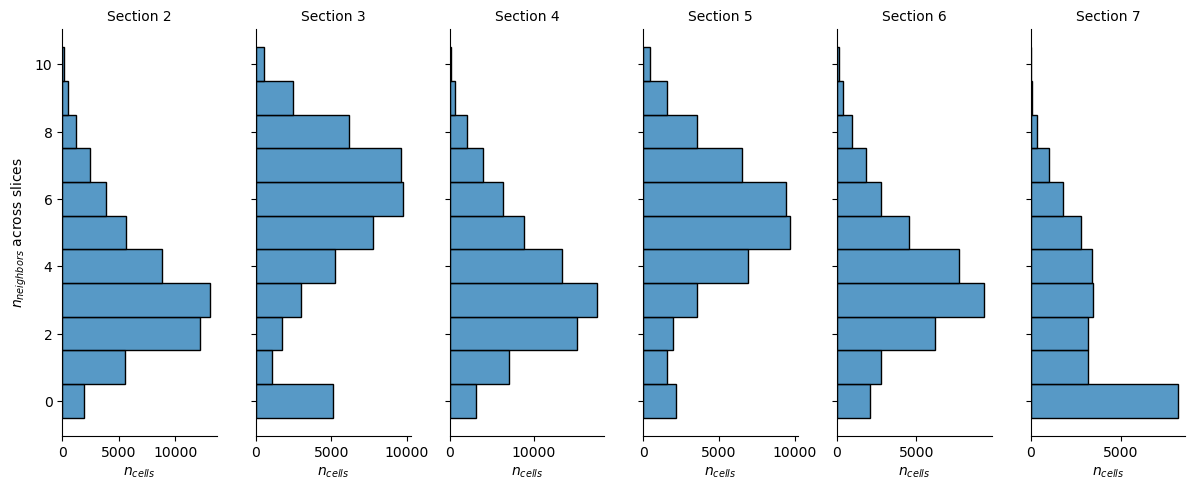

In [6]:
from scipy.sparse import csr_array

# count neighbors within and across slices
neighbor_stats = []
for g, idx in adata.obs.groupby("n_section").indices.items():
    distances = csr_array(adata.obsp["spatial_distances"][idx, :])
    out_of_slice_idx = list(set(range(distances.shape[1])) - set(idx))

    n_in = distances[:, idx].count_nonzero(axis=1)
    n_out = distances[:, out_of_slice_idx].count_nonzero(axis=1)

    neighbor_stats.append(
        pd.DataFrame({"slice": g, "n_neigh_in": n_in, "n_neigh_out": n_out})
    )

neighbor_stats = pd.concat(neighbor_stats)

# plot the number of out-of-slice neighbors per cell across sections
g = sns.FacetGrid(neighbor_stats, col="slice", height=5, aspect=0.4, sharex=False)
_ = g.map_dataframe(sns.histplot, y="n_neigh_out", discrete=True)
_ = g.set_titles(col_template="Section {col_name}")
_ = g.set_axis_labels(x_var=r"$n_{cells}$", y_var=r"$n_{neighbors}$ across slices")

We do observe some differences in the distribution of neighbors that are in a different slice, however, this is partially due to the shape and overlap of the sections and will become apparent later.

Now, we can run spatialleiden we would do with 2D datasets.

In [7]:
spatialleiden(
    adata, directed=(False, True), layer_ratio=1.8, random_state=seed, n_iterations=5
)

## Visualizing the domains

After defining spatial domains with spatialleiden, we can check that these are actually spatially continuous across sections.

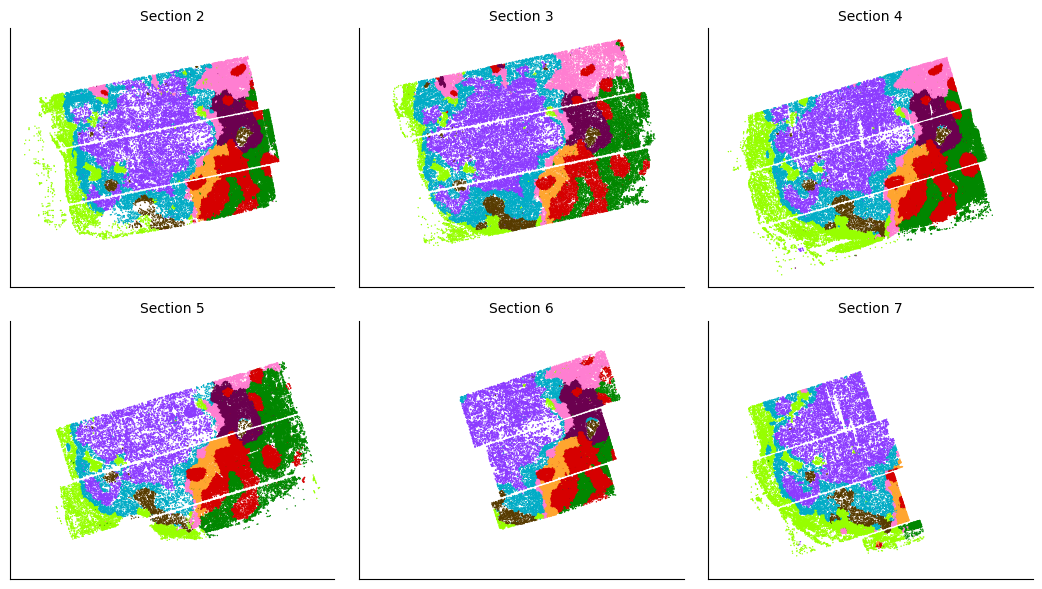

In [8]:
def remove_tick_and_label(ax):
    ax.set(xticklabels=[], yticklabels=[], xlabel=None, ylabel=None)
    ax.tick_params(left=False, bottom=False)


# dataframe of coordinates and domains
labels = adata.obs[["spatialleiden", "n_section"]]
labels.loc[:, ["x", "y", "z"]] = adata.obsm["spatial_3d_aligned"]

palette = sns.color_palette(
    cc.glasbey, n_colors=labels["spatialleiden"].cat.categories.size
)

scatter_kwargs = dict(x="x", y="y", hue="spatialleiden", palette=palette, s=1, lw=0)


g = sns.FacetGrid(labels, col="n_section", col_wrap=3, aspect=1.2, legend_out=True)
_ = g.map_dataframe(sns.scatterplot, **scatter_kwargs)
_ = g.set(aspect=1)
_ = g.set_titles(col_template="Section {col_name}")
for ax in g.axes.flat:
    remove_tick_and_label(ax)

_ = g.tight_layout()

The overlap of the sections and continuity of the domains can even better be visualized using an animated plot.

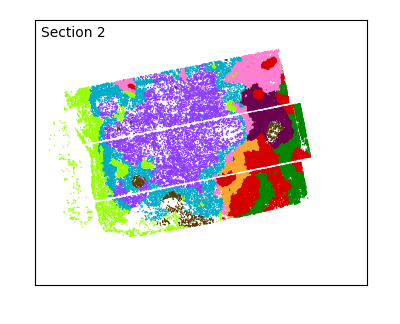

In [9]:
from celluloid import Camera
from IPython.display import Image

fig, ax = plt.subplots(figsize=(4, 3.25))
ax.set(aspect=1)
fig.tight_layout()

camera = Camera(fig)
for i, sdf in labels.groupby("n_section", observed=True):
    _ = sns.scatterplot(sdf, ax=ax, legend=False, **scatter_kwargs)
    ax.text(
        0.02,
        0.98,
        f"Section {i}",
        ha="left",
        va="top",
        transform=ax.transAxes,
    )
    remove_tick_and_label(ax)

    camera.snap()

plt.close(fig)

animation = camera.animate()
_ = animation.save("lymphnode.gif", fps=1)

Image(filename="lymphnode.gif")